In [1]:
# Install Required Libraries
%pip install tensorflow pandas matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [5]:
# Load Dataset

# Upload alcohol_sales.csv file first
data = pd.read_csv("Alcohol_Sales.csv")

# Display First 5 Rows
print(data.head())

     Month   Sales
0  2015-01  209.93
1  2015-02  215.33
2  2015-03  247.60
3  2015-04  278.71
4  2015-05  253.11


In [6]:
# Select Sales Column

sales_data = data.iloc[:,1].values.reshape(-1,1)

# Normalize Data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(sales_data)

print(scaled_data[:5])

[[0.14536818]
 [0.15908456]
 [0.2410526 ]
 [0.32007417]
 [0.25504839]]


In [7]:
# Create Dataset Function

def create_dataset(dataset, time_step=3):
    
    X, Y = [], []
    
    for i in range(len(dataset)-time_step-1):
        
        a = dataset[i:(i+time_step), 0]
        
        X.append(a)
        Y.append(dataset[i + time_step, 0])
        
    return np.array(X), np.array(Y)

# Create Sequences
time_step = 3

X, y = create_dataset(scaled_data, time_step)

print(X.shape)
print(y.shape)

(116, 3)
(116,)


In [8]:
# Reshape Data for RNN

X = X.reshape(X.shape[0], X.shape[1], 1)

print(X.shape)

(116, 3, 1)


In [9]:
# Create RNN Model

model = Sequential()

model.add(SimpleRNN(
    50,
    activation='tanh',
    input_shape=(time_step,1)
))

model.add(Dense(1))

# Compile Model
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Model Summary
model.summary()

/opt/intel/oneapi/intelpython/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train Model

history = model.fit(
    X,
    y,
    epochs=50,
    batch_size=8,
    verbose=1
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1133   
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0274 
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0151 
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0106 
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0101 
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0102 
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0097 
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0090 
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0088 
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0086 
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0082 
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0081 
Epoch 13/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0078 
Epoch 14/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0076 
Epoch 15/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0075 
Ep

In [11]:
# Predictions

predictions = model.predict(X)

# Convert Back to Original Scale
predictions = scaler.inverse_transform(predictions)

actual = scaler.inverse_transform(y.reshape(-1,1))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step 


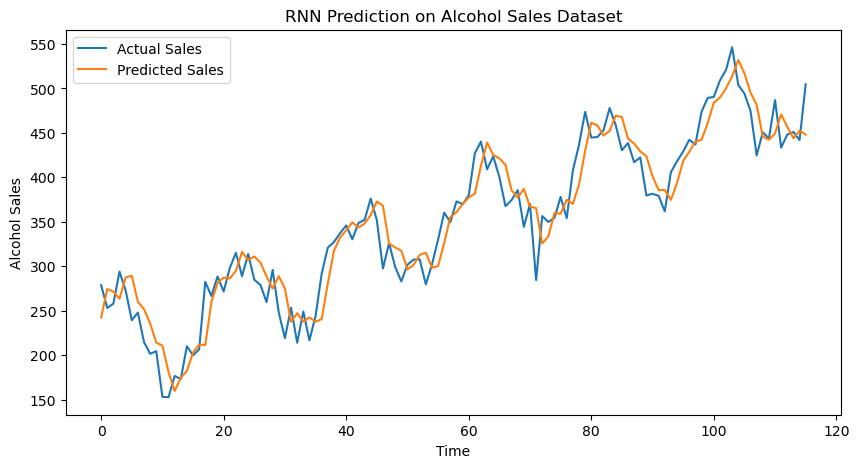

In [12]:
# Plot Results

plt.figure(figsize=(10,5))

plt.plot(actual, label="Actual Sales")

plt.plot(predictions, label="Predicted Sales")

plt.xlabel("Time")

plt.ylabel("Alcohol Sales")

plt.title("RNN Prediction on Alcohol Sales Dataset")

plt.legend()

plt.show()